In [1]:
import json, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from pathlib import Path

BASE = Path('../outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1/seed3/data/classifiers/finetuning')
N_RUNS = 3
METRIC = 'test_f1'  # change to: train_f1, test_f1, train_loss, test_loss

# ── Choose which mode to analyse ──────────────────────────────────────────────
# Mode 2: fine-tune projector head only (frozen backbone)
# Mode 3: fine-tune full network
MODE = 2

In [2]:
rows = []
for config_dir in sorted(BASE.glob('initial_pure_cwNone*_mode*_ep40')):
    run_name = config_dir.name
    m = re.search(r'mode(\d)_lr([^_]+)_wd([^_]+)_do([^_]+)', run_name)
    if not m:
        continue
    mode, lr, wd, do = m.groups()
    if int(mode) != MODE:
        continue

    metrics_path = config_dir / 'finetuning_metrics.json'
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        met = json.load(f)

    # macro_f1: list of [scalar] per run
    train_f1 = float(np.mean([v[0] for v in met['macro_f1']['train']]))
    test_f1  = float(np.mean([v[0] for v in met['macro_f1']['test']]))
    train_f1_std = float(np.std([v[0] for v in met['macro_f1']['train']]))
    test_f1_std  = float(np.std([v[0] for v in met['macro_f1']['test']]))

    # final-epoch losses from checkpoints
    train_losses_final, test_losses_final = [], []
    for ri in range(1, N_RUNS + 1):
        ckpt_path = config_dir / f'run{ri}' / f'finetuned_model_{ri}.pt'
        if ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
            train_losses_final.append(ckpt['train_losses'][-1])
            test_losses_final.append(ckpt['test_losses'][-1])

    rows.append(dict(
        mode=int(mode), lr=lr, wd=wd, dropout=float(do),
        train_loss=float(np.mean(train_losses_final)) if train_losses_final else np.nan,
        test_loss =float(np.mean(test_losses_final))  if test_losses_final  else np.nan,
        train_f1=train_f1, train_f1_std=train_f1_std,
        test_f1 =test_f1,  test_f1_std =test_f1_std,
        n_complete=len(train_losses_final),
    ))

print(f"BASE = {BASE}  (exists: {BASE.exists()})")
print(f"MODE = {MODE}")
_all_dirs = sorted(BASE.glob('initial_pure_cwNone*_mode*_ep40'))
_mode_dirs = [d for d in _all_dirs if f'_mode{MODE}_' in d.name]
print(f"  {len(_mode_dirs)} dir(s) matched for mode={MODE}, {len(rows)} had finetuning_metrics.json")

df = pd.DataFrame(rows)
if df.empty:
    print("No data loaded — check BASE path, MODE, and glob pattern.")
else:
    print(f'{len(df)} configs loaded   |   {df["n_complete"].sum()} / {len(df)*N_RUNS} runs complete')
    df.sort_values(METRIC, ascending=False).head(10)

BASE = ../outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1/seed3/data/classifiers/finetuning  (exists: True)
MODE = 2
  28 dir(s) matched for mode=2, 27 had finetuning_metrics.json
27 configs loaded   |   81 / 81 runs complete


In [3]:
# ── Ranked table ──────────────────────────────────────────────────────────────
cols = ['mode', 'lr', 'wd', 'dropout', 'train_loss', 'test_loss', 'train_f1', 'test_f1']
df[cols].sort_values('test_f1', ascending=False).style \
    .background_gradient(subset=['test_f1', 'train_f1'], cmap='YlGn') \
    .background_gradient(subset=['test_loss', 'train_loss'], cmap='YlOrRd_r') \
    .format({c: '{:.4f}' for c in ['train_loss', 'test_loss', 'train_f1', 'test_f1']})

,mode,lr,wd,dropout,train_loss,test_loss,train_f1,test_f1
5,2,1e-1,3e-1,0.400000,0.1427,0.1996,0.7689,0.6363
9,2,1e-2,1e-1,0.000000,0.0356,0.5318,0.9667,0.6363
14,2,1e-2,3e-1,0.400000,0.0588,0.4097,0.9292,0.6328
12,2,1e-2,3e-1,0.000000,0.0545,0.4277,0.9218,0.6314
19,2,1e-3,1e-1,0.200000,0.0287,0.5142,0.9716,0.6296
15,2,1e-2,3e-2,0.000000,0.0266,0.6576,0.9750,0.6265
4,2,1e-1,3e-1,0.200000,0.1393,0.2032,0.7780,0.6244
2,2,1e-1,1e-1,0.400000,0.1157,0.2644,0.8254,0.6243
3,2,1e-1,3e-1,0.000000,0.1423,0.1985,0.7685,0.6227
23,2,1e-3,3e-1,0.400000,0.0369,0.4667,0.9649,0.6222


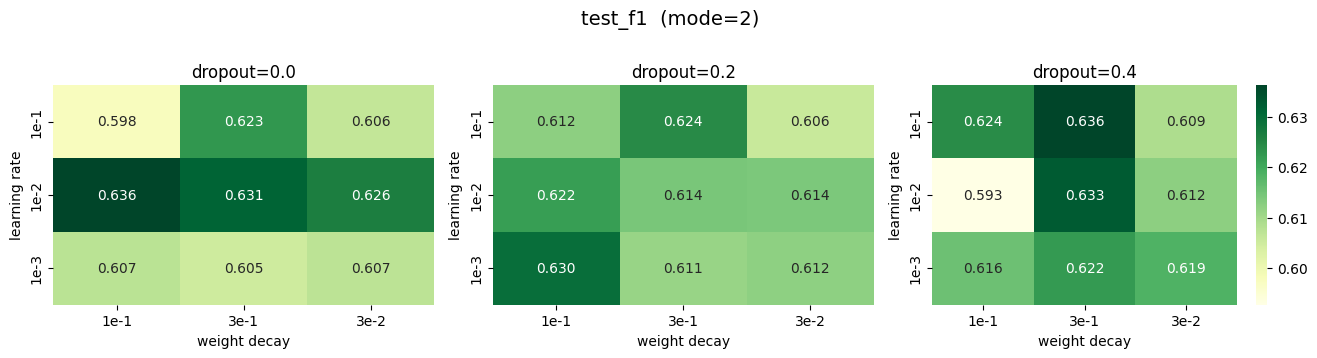

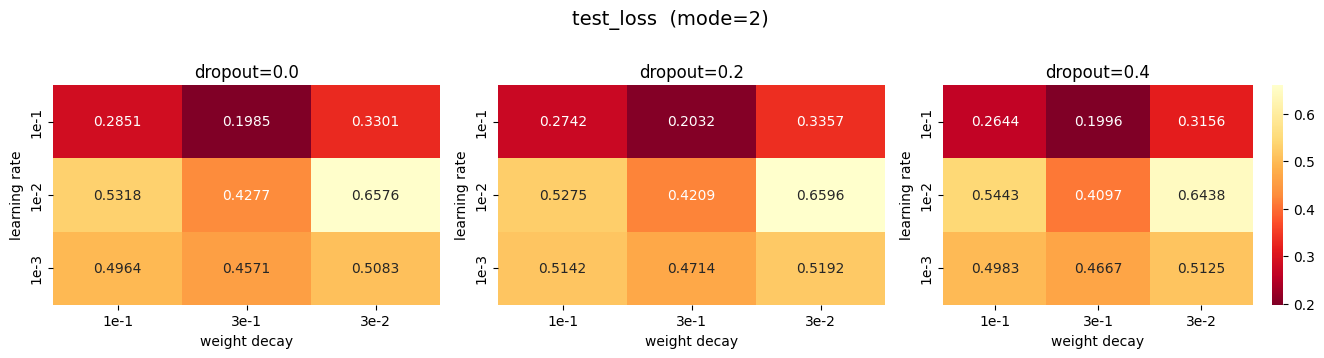

In [4]:
# ── Heatmaps: lr × wd, faceted by dropout ─────────────────────────────────────
dropouts = sorted(df['dropout'].unique())

for metric, cmap, fmt in [('test_f1', 'YlGn', '.3f'), ('test_loss', 'YlOrRd_r', '.4f')]:
    vmin = df[metric].min()
    vmax = df[metric].max()
    fig, axes = plt.subplots(1, len(dropouts),
                             figsize=(4.5 * len(dropouts), 3.5),
                             squeeze=False)
    for c, do in enumerate(dropouts):
        ax = axes[0][c]
        sub = df[df.dropout == do]
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot_table(index='lr', columns='wd', values=metric)
        sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                    vmin=vmin, vmax=vmax, cbar=(c == len(dropouts)-1))
        ax.set_title(f'dropout={do}')
        ax.set_xlabel('weight decay')
        ax.set_ylabel('learning rate')
    fig.suptitle(f'{metric}  (mode={MODE})', fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()

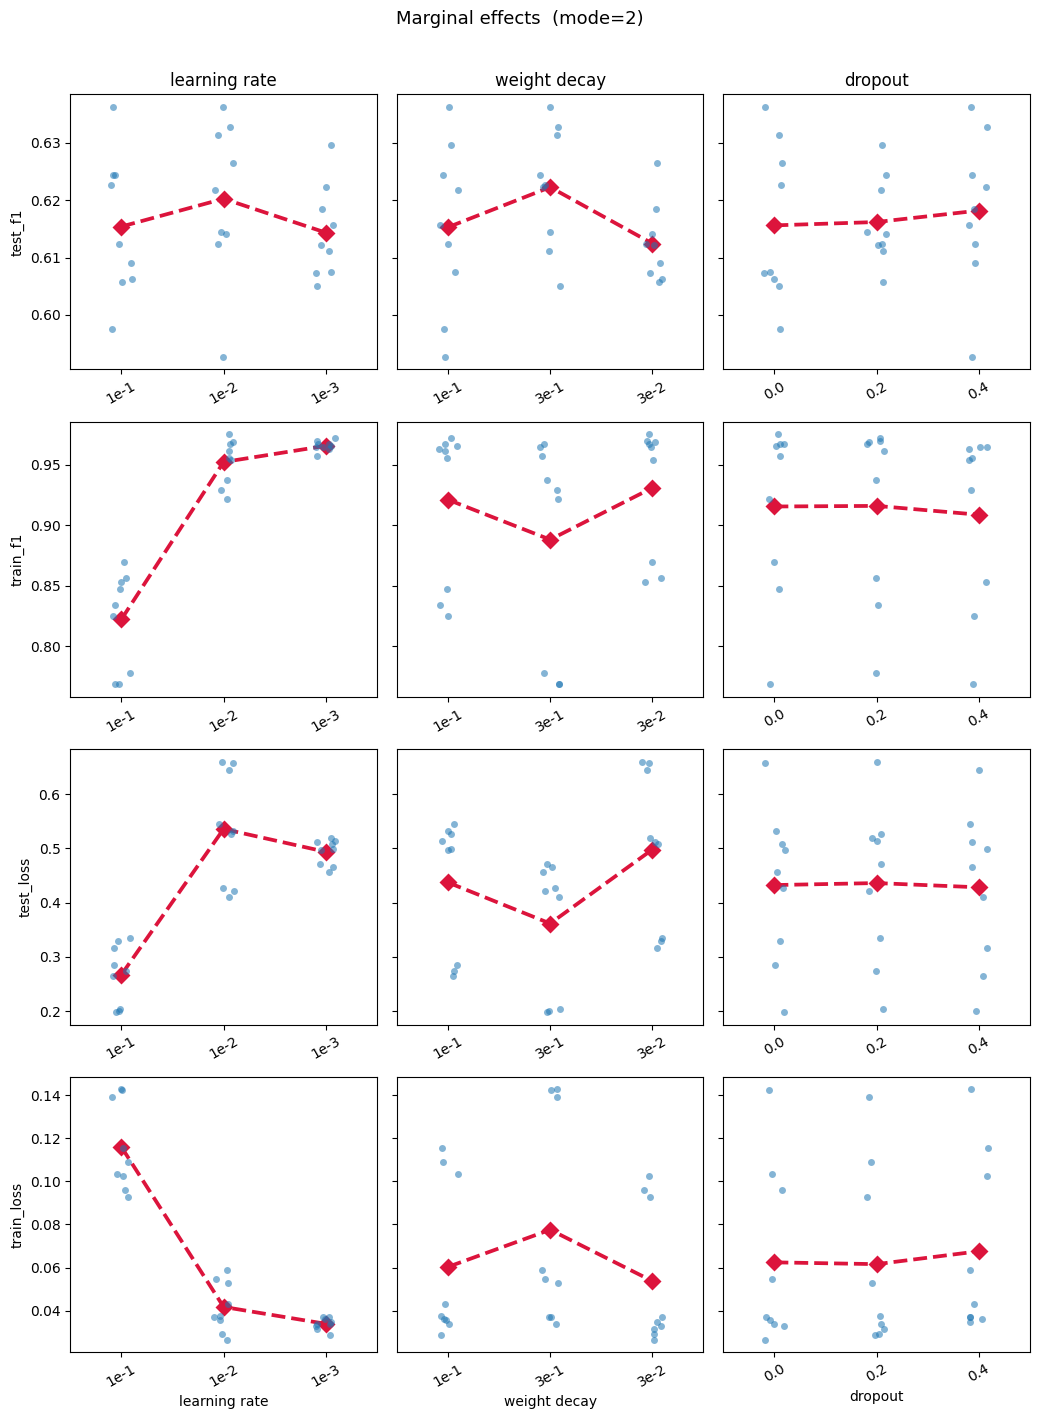

In [5]:
# ── Marginal effect of each hyperparameter ────────────────────────────────────
hp_cols       = ['lr', 'wd', 'dropout']
hp_labels     = {'lr': 'learning rate', 'wd': 'weight decay', 'dropout': 'dropout'}
metrics       = ['test_f1', 'train_f1', 'test_loss', 'train_loss']

fig, axes = plt.subplots(len(metrics), len(hp_cols),
                         figsize=(3.5 * len(hp_cols), 3.5 * len(metrics)),
                         sharey='row')
for ri, met in enumerate(metrics):
    for ci, col in enumerate(hp_cols):
        ax = axes[ri][ci]
        order = sorted(df[col].dropna().unique(), key=str)
        sns.stripplot(data=df, x=col, y=met, ax=ax, order=order,
                      jitter=True, size=5, alpha=0.55)
        sns.pointplot(data=df, x=col, y=met, ax=ax, order=order,
                      estimator='mean', color='crimson', markers='D',
                      linestyles='--', errorbar=None)
        ax.set_xlabel(hp_labels[col] if ri == len(metrics)-1 else '')
        ax.set_ylabel(met if ci == 0 else '')
        ax.set_title('' if ri > 0 else hp_labels[col])
        ax.tick_params(axis='x', labelrotation=30)

fig.suptitle(f'Marginal effects  (mode={MODE})', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

Config dir: initial_pure_cwNone0.0_mode2_lr1e-3_wd3e-2_do0.2_ep40  (exists: True)


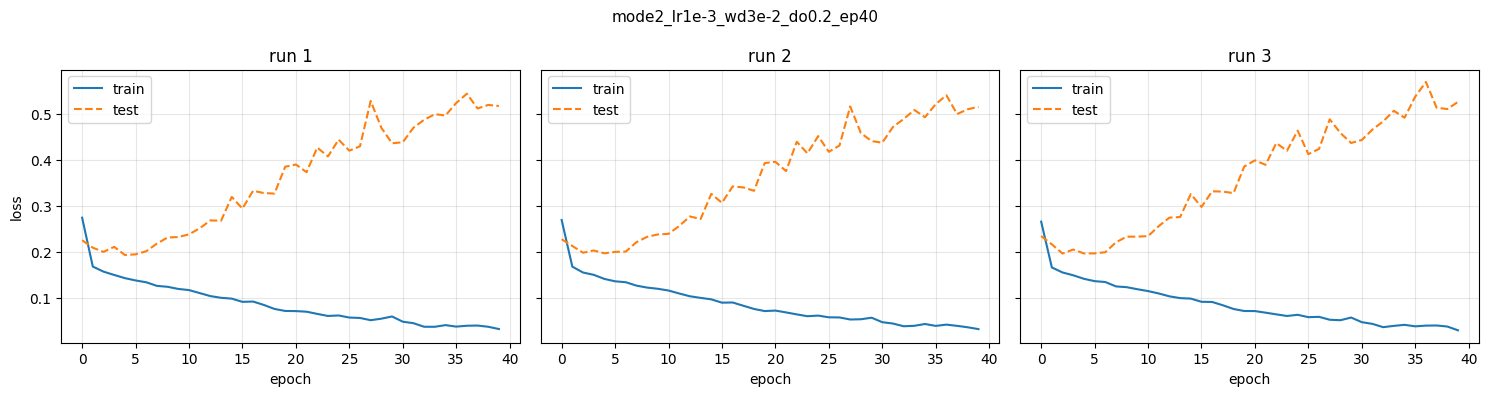

In [6]:
# ── Loss curves for a specific config ────────────────────────────────────────
# Change LR/WD/DO to inspect a specific config
INSPECT_LR   = '1e-3'
INSPECT_WD   = '3e-2'
INSPECT_DO   = 0.2

run_name  = f'mode{MODE}_lr{INSPECT_LR}_wd{INSPECT_WD}_do{INSPECT_DO}_ep40'
_matches = sorted(BASE.glob(f'initial_pure_cwNone*_{run_name}'))
config_dir = _matches[0] if _matches else BASE / f'initial_pure_cwNone0.0_{run_name}'
print(f'Config dir: {config_dir.name}  (exists: {config_dir.exists()})')

fig, axes = plt.subplots(1, N_RUNS, figsize=(5 * N_RUNS, 4), sharey=True)
for ri in range(1, N_RUNS + 1):
    ax = axes[ri - 1]
    ckpt_path = config_dir / f'run{ri}' / f'finetuned_model_{ri}.pt'
    if not ckpt_path.exists():
        ax.set_title(f'run{ri}: missing')
        continue
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    ax.plot(ckpt['train_losses'], label='train')
    ax.plot(ckpt['test_losses'],  label='test', linestyle='--')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss' if ri == 1 else '')
    ax.set_title(f'run {ri}')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(run_name, fontsize=11)
fig.tight_layout()
plt.show()